# Analyses of Traffic Patterns by Sport and Outcome

In [135]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import folium
from folium.plugins import HeatMap
import seaborn as sns
import matplotlib.pyplot as plt

Need to merge all game information with the stops information. So like whether they won the game, score diff, things like that. Ultimately want to produce faceted plots based on W/non-W home games for each sport.

In [136]:
philly_stops = pd.read_csv("/home/jasmine/PROJECTS/sds357-project-sp26-i-love-philly/data/DATA_WITH_DISTANCES_KM.csv")
philly_stops

/tmp/ipykernel_76520/2969800158.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  philly_stops = pd.read_csv("/home/jasmine/PROJECTS/sds357-project-sp26-i-love-philly/data/DATA_WITH_DISTANCES_KM.csv")


,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,flyers_home_game,flyers_away_game,distance_from_eagles,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,False,False,6.689936,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,False,False,3.648924,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,False,False,6.913681,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,False,False,3.424703,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,False,False,6.693603,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211


In [137]:
eagles = pd.read_csv("../data/cleanedEaglesData.csv")
eagles

,Game,Day,Date,StartTime,xEndTime,Home,Opp,TeamScore,OppScore,PointDiff,...,Wins,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl
0,1,Sunday,2014-09-07,13:02:00,16:14:00,0,Jacksonville Jaguars,34,17,17,...,1,0,1,0,0,0,1,0,0,0
1,2,Monday,2014-09-15,20:31:00,23:43:00,1,Indianapolis Colts,30,27,3,...,2,0,2,0,0,0,1,0,0,0
2,3,Sunday,2014-09-21,13:02:00,16:14:00,0,Washington Redskins,37,34,3,...,3,0,3,0,0,0,1,0,0,0
3,4,Sunday,2014-09-28,16:25:00,19:37:00,1,San Francisco 49ers,21,26,-5,...,3,1,-1,0,0,0,1,0,0,0
4,5,Sunday,2014-10-05,13:02:00,16:14:00,0,St. Louis Rams,34,28,6,...,4,1,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,16,Monday,2017-12-25,20:30:00,23:42:00,0,Oakland Raiders,19,10,9,...,13,2,3,0,0,0,1,0,0,0
63,17,Sunday,2017-12-31,13:00:00,16:12:00,0,Dallas Cowboys,0,6,-6,...,13,3,-1,1,0,1,1,0,0,0
64,Division,Saturday,2018-01-13,16:35:00,19:47:00,0,Atlanta Falcons,15,10,5,...,14,3,1,0,0,0,0,1,0,0
65,Conf. Champ.,Sunday,2018-01-21,18:40:00,21:52:00,0,Minnesota Vikings,38,7,31,...,15,3,2,0,0,0,0,0,1,0


In [138]:
eagles.columns

Index(['Game', 'Day', 'Date', 'StartTime', 'xEndTime', 'Home', 'Opp',
       'TeamScore', 'OppScore', 'PointDiff', 'DefTO', 'OffTO', 'TODiff', 'Win',
       'OT', 'Season', 'Wins', 'Losses', 'Streak', 'Rivalry', 'Giants',
       'Cowboys', 'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl'],
      dtype='object')

In [139]:
eagles_win = eagles[['Date', 'Win', "PointDiff", "Streak"]].copy() 

main_df = pd.merge(
    philly_stops, 
    eagles_win,
    left_on='date', 
    right_on='Date',
    how='left'                    
)
main_df = main_df.drop(columns=['Date'])
main_df = main_df.rename(columns={'Win': 'eagles_win',
                                  "PointDiff": "eagles_point_diff",
                                  "Streak": "eagles_streak"})

main_df[main_df["eagles_home_game"] == 1]

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,eagles_win,eagles_point_diff,eagles_streak
264920,216366,2014-09-15,00:00:00,1200 BLOCK S 26TH ST,39.938690,-75.186919,17.0,172,32.0,black,...,2.705243,2.496440,2.705243,4.457695,4.353656,4.017621,4.353656,1.0,3.0,2.0
264921,320076,2014-09-15,00:00:00,2600 BLOCK N FRONT ST,39.989349,-75.131270,26.0,261,24.0,white,...,6.454824,6.040586,6.454824,10.246953,10.388006,9.721357,10.388006,1.0,3.0,2.0
264922,205399,2014-09-15,00:00:00,4400 BLOCK FRANKFORD AV,40.012579,-75.087572,15.0,151,38.0,white,...,8.896308,8.457476,8.896308,14.112038,14.317184,13.610955,14.317184,1.0,3.0,2.0
264923,111643,2014-09-15,00:00:00,7100 BLOCK CASTOR AV,40.048152,-75.069087,2.0,023,24.0,black,...,11.516707,11.080951,11.516707,18.339254,18.534297,17.833018,18.534297,1.0,3.0,2.0
264924,295845,2014-09-15,00:01:00,N 63RD ST / MASTER ST,39.972184,-75.244937,19.0,192,28.0,black,...,6.244179,6.175756,6.244179,10.269533,10.049007,9.938891,10.049007,1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640377,1633851,2017-12-17,23:41:00,2300 BLOCK W LEHIGH AV,39.995880,-75.169186,39.0,393,28.0,black,...,6.533975,6.195844,6.533975,10.491306,10.515388,9.971220,10.515388,1.0,5.0,2.0
1640378,1512494,2017-12-17,23:50:00,5600 BLOCK LANGDON ST,40.033320,-75.093339,2.0,21,22.0,black,...,10.026376,9.598178,10.026376,15.962558,16.135849,15.446732,16.135849,1.0,5.0,2.0
1640379,1631086,2017-12-17,23:50:00,HARVEY ST / MC CALLUM ST,40.037508,-75.179399,14.0,143,23.0,black,...,9.412518,9.092076,9.412518,15.146121,15.147942,14.632241,15.147942,1.0,5.0,2.0
1640380,1626762,2017-12-17,23:56:00,2900 BLOCK W ALLEGHENY AV,40.004672,-75.176977,39.0,393,45.0,black,...,7.143719,6.823479,7.143719,11.494560,11.496673,10.981298,11.496673,1.0,5.0,2.0


In [140]:
main_df

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,eagles_win,eagles_point_diff,eagles_streak
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,NaN,NaN,NaN
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,NaN,NaN,NaN
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634,NaN,NaN,NaN
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497,NaN,NaN,NaN
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922,NaN,NaN,NaN
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393,NaN,NaN,NaN
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,NaN,NaN,NaN
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,NaN,NaN,NaN


In [141]:
main_df[main_df["eagles_home_game"] == 0]

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,eagles_win,eagles_point_diff,eagles_streak
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,NaN,NaN,NaN
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,NaN,NaN,NaN
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634,NaN,NaN,NaN
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497,NaN,NaN,NaN
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922,NaN,NaN,NaN
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393,NaN,NaN,NaN
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,NaN,NaN,NaN
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,NaN,NaN,NaN


In [142]:
s76ers = pd.read_csv("../data/cleaned76ersData.csv")
s76ers

,Game,Day,Date,StartTime,LOG,EndTime,Home,Attendance,Opp,TeamScore,...,PointDiff,Win,OT,Season,Wins,Losses,Streak,Rivalry,Celtics,Knicks
0,31,Wednesday,2014-01-01,21:00:00,134,23:14:00,1,16006,Denver Nuggets,114,...,12,1,0,2013,10,21,1,0,0,0
1,32,Thursday,2014-01-02,22:00:00,143,00:23:00,1,16259,Sacramento Kings,113,...,9,1,0,2013,11,21,2,0,0,0
2,33,Saturday,2014-01-04,22:00:00,145,00:25:00,1,20004,Portland Trail Blazers,101,...,2,1,0,2013,12,21,3,0,0,0
3,34,Monday,2014-01-06,19:00:00,121,21:01:00,0,10736,Minnesota Timberwolves,95,...,-31,0,0,2013,12,22,-1,0,0,0
4,35,Tuesday,2014-01-07,19:00:00,127,21:07:00,1,13344,Cleveland Cavaliers,93,...,-18,0,0,2013,12,23,-2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,78,Wednesday,2018-04-04,19:00:00,131,21:11:00,1,18395,Detroit Pistons,115,...,7,1,0,2017,48,30,12,0,0,0
376,79,Friday,2018-04-06,19:00:00,146,21:26:00,0,20769,Cleveland Cavaliers,132,...,2,1,0,2017,49,30,13,0,0,0
377,80,Sunday,2018-04-08,13:00:00,122,15:02:00,0,20846,Dallas Mavericks,109,...,12,1,0,2017,50,30,14,0,0,0
378,81,Tuesday,2018-04-10,19:30:00,140,21:50:00,1,15673,Atlanta Hawks,121,...,8,1,0,2017,51,30,15,0,0,0


In [143]:
s76ers_win = s76ers[['Date', 'Win', "PointDiff", "Streak"]].copy() 

main_df = pd.merge(
    main_df, 
    s76ers_win,
    left_on='date', 
    right_on="Date",
    how='left'                    
)
main_df = main_df.drop(columns=['Date'])
main_df = main_df.rename(columns={'Win': '76ers_win',
                                  "PointDiff": "76ers_point_diff",
                                  "Streak": "76ers_streak"})

main_df[main_df["76ers_home_game"] == 1]

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,eagles_win,eagles_point_diff,eagles_streak,76ers_win,76ers_point_diff,76ers_streak
262,280499,2014-01-06,00:14:00,1800 BLOCK E SOMERSET ST,39.991396,-75.122592,24.0,242,32.0,white,...,10.707342,10.868561,10.186994,10.868561,NaN,NaN,NaN,0.0,-31.0,-1.0
263,249336,2014-01-06,03:10:00,2200 BLOCK N UBER ST,39.987485,-75.165022,22.0,221,18.0,black,...,9.560809,9.599018,9.037300,9.599018,NaN,NaN,NaN,0.0,-31.0,-1.0
264,232893,2014-01-06,10:45:00,5900 BLOCK W COLUMBIA AV,39.981409,-75.239387,19.0,191,18.0,black,...,10.796370,10.605834,10.426976,10.605834,NaN,NaN,NaN,0.0,-31.0,-1.0
265,280500,2014-01-06,11:25:00,3400 BLOCK KENSINGTON AV,39.999085,-75.108741,24.0,241,62.0,hispanic,...,11.955845,12.138714,11.443589,12.138714,NaN,NaN,NaN,0.0,-31.0,-1.0
266,156259,2014-01-06,12:39:00,5700 BLOCK SPRINGFIELD AV,39.937531,-75.228533,12.0,124,25.0,black,...,6.575071,6.295436,6.348512,6.295436,NaN,NaN,NaN,0.0,-31.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756889,1784544,2018-04-11,23:50:00,E OLNEY AV / E TABOR RD,40.030807,-75.112031,35.0,352,28.0,black,...,15.132507,15.275542,14.607657,15.275542,NaN,NaN,NaN,1.0,35.0,16.0
1756890,1782594,2018-04-11,23:53:00,100 BLOCK W RITTENHOUSE ST,40.036482,-75.177694,14.0,143,52.0,black,...,15.023413,15.028723,14.508341,15.028723,NaN,NaN,NaN,1.0,35.0,16.0
1756891,1782588,2018-04-11,23:53:00,100 BLOCK W RITTENHOUSE ST,40.036482,-75.177694,14.0,143,28.0,black,...,15.023413,15.028723,14.508341,15.028723,NaN,NaN,NaN,1.0,35.0,16.0
1756892,1788276,2018-04-11,23:55:00,1300 BLOCK CATHARINE ST,39.940638,-75.165092,3.0,031,33.0,black,...,4.361938,4.418518,3.836701,4.418518,NaN,NaN,NaN,1.0,35.0,16.0


In [144]:
flyers = pd.read_csv("../data/cleanedFlyersData.csv")
flyers

,Game,Day,Date,xStartTime,xLOG,xEndTime,Home,Attendance,Opp,TeamScore,...,Season,Wins,Losses,Streak,Rivalry,Penguins,Rangers,Devils,RegularSeason,ConfQF
0,41,Thursday,2014-01-02,19:00:00,150,21:30:00,1,NaN,Colorado Avalanche,1,...,2013,20,17,-1,0,0,0,0,1,0
1,42,Saturday,2014-01-04,17:00:00,150,19:30:00,1,NaN,Phoenix Coyotes,5,...,2013,21,17,1,0,0,0,0,1,0
2,43,Tuesday,2014-01-07,19:00:00,150,21:30:00,1,NaN,New Jersey Devils,3,...,2013,22,17,2,1,0,0,1,1,0
3,44,Wednesday,2014-01-08,19:00:00,150,21:30:00,0,NaN,Montreal Canadiens,3,...,2013,23,17,3,0,0,0,0,1,0
4,45,Saturday,2014-01-11,17:00:00,150,19:30:00,0,NaN,Tampa Bay Lightning,3,...,2013,23,18,-1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,2,Friday,2018-04-13,19:00:00,155,21:35:00,1,18648.0,Pittsburgh Penguins,5,...,2017,1,1,1,1,1,0,0,0,1
385,3,Sunday,2018-04-15,17:00:00,152,19:32:00,0,19955.0,Pittsburgh Penguins,1,...,2017,1,2,-1,1,1,0,0,0,1
386,4,Wednesday,2018-04-18,19:00:00,146,21:26:00,0,19644.0,Pittsburgh Penguins,0,...,2017,1,3,-2,1,1,0,0,0,1
387,5,Friday,2018-04-20,19:00:00,151,21:31:00,1,18632.0,Pittsburgh Penguins,4,...,2017,2,3,1,1,1,0,0,0,1


In [145]:
flyers_win = flyers[['Date', 'Win', "PointDiff", "Streak"]].copy() 

main_df = pd.merge(
    main_df, 
    flyers_win,
    left_on='date', 
    right_on='Date',
    how='left'                    
)
main_df = main_df.drop(columns=['Date'])
main_df = main_df.rename(columns={'Win': 'flyers_win',
                                  "PointDiff": "flyers_point_diff",
                                  "Streak": "flyers_streak"})

main_df[main_df["flyers_home_game"] == 1]

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_flyers_km,eagles_win,eagles_point_diff,eagles_streak,76ers_win,76ers_point_diff,76ers_streak,flyers_win,flyers_point_diff,flyers_streak
336,275329,2014-01-08,01:55:00,3100 BLOCK F ST,39.995444,-75.117785,24.0,242,34.0,white,...,11.443982,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0
337,233315,2014-01-08,02:10:00,N 52ND ST / HAVERFORD AV,39.964905,-75.224593,19.0,191,28.0,black,...,8.381046,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0
338,275330,2014-01-08,03:00:00,2800 BLOCK BOUDINOT ST,39.991599,-75.123583,24.0,242,37.0,hispanic,...,10.856669,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0
339,233316,2014-01-08,03:35:00,N 52ND ST / LANCASTER AV,39.977220,-75.226768,19.0,192,24.0,black,...,9.651858,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0
340,217950,2014-01-08,06:40:00,S 53RD ST / MARKET ST,39.960248,-75.226853,18.0,182,41.0,black,...,8.060385,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752456,1778822,2018-04-07,23:51:00,100 BLOCK W ALLEGHENY AV,39.998509,-75.129288,25.0,253,28.0,hispanic,...,11.404457,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,2.0
1752457,1769258,2018-04-07,23:52:00,4100 BLOCK N FRONT ST,40.012372,-75.126382,25.0,252,30.0,hispanic,...,12.944648,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,2.0
1752458,1771740,2018-04-07,23:55:00,2700 BLOCK S 63RD ST,39.921645,-75.224944,12.0,123,74.0,white,...,5.064216,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,2.0
1752459,1771290,2018-04-07,23:55:00,3600 BLOCK OLD YORK RD,40.007249,-75.147964,25.0,254,33.0,white,...,11.952729,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,2.0


In [146]:
phillies = pd.read_csv("../data/cleanedPhilliesData.csv")
phillies

,Game,Day,Date,StartTime,LOG,EndTime,DayGame,Rank,CLI,Home,...,TeamScore,OppScore,PointDiff,Win,Walkoff,Season,Streak,Rivalry,Mets,Braves
0,1,Monday,2014-03-31,14:05:00,216,17:41:00,1,1,0.96,1,...,14,10,4,1,0,2014,1,0,0,0
1,2,Tuesday,2014-04-01,20:05:00,194,23:19:00,0,3,0.98,1,...,2,3,-1,0,1,2014,-1,0,0,0
2,3,Wednesday,2014-04-02,20:05:00,182,23:07:00,0,4,0.88,1,...,3,4,-1,0,1,2014,-2,0,0,0
3,4,Friday,2014-04-04,14:20:00,196,17:36:00,1,4,0.88,1,...,7,2,5,1,0,2014,1,0,0,0
4,5,Saturday,2014-04-05,14:20:00,173,17:13:00,1,3,0.92,1,...,2,0,2,1,0,2014,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,158,Wednesday,2018-09-26,20:40:00,171,23:31:00,0,3,0.00,1,...,0,14,-14,0,0,2018,-7,0,0,0
807,159,Thursday,2018-09-27,15:10:00,186,18:16:00,1,3,0.00,1,...,3,5,-2,0,0,2018,-8,0,0,0
808,160,Friday,2018-09-28,19:05:00,222,22:47:00,0,3,0.00,0,...,2,10,-8,0,0,2018,-9,1,0,1
809,161,Saturday,2018-09-29,19:05:00,163,21:48:00,0,3,0.00,0,...,3,0,3,1,0,2018,1,1,0,1


In [147]:
phillies_win = phillies[['Date', 'Win', "PointDiff", "Streak"]].copy() 

main_df = pd.merge(
    main_df, 
    phillies_win,
    left_on='date', 
    right_on='Date',
    how='left'                    
)
main_df = main_df.drop(columns=['Date'])
main_df = main_df.rename(columns={'Win': 'phillies_win',
                                  "PointDiff": "phillies_point_diff",
                                  "Streak": "phillies_streak"})

main_df[main_df["phillies_home_game"] == 1]

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,eagles_streak,76ers_win,76ers_point_diff,76ers_streak,flyers_win,flyers_point_diff,flyers_streak,phillies_win,phillies_point_diff,phillies_streak
73708,261392,2014-04-08,00:00:00,N 63RD ST / SHERWOOD RD,39.987363,-75.249106,19.0,191,51.0,black,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,0.0,-6.0,-2.0
73709,241589,2014-04-08,00:00:00,S 60TH ST / MARKET ST,39.961969,-75.240764,18.0,182,37.0,black,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,0.0,-6.0,-2.0
73710,316282,2014-04-08,00:01:00,1300 BLOCK N FRONT ST,39.970403,-75.135816,26.0,263,25.0,white,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,0.0,-6.0,-2.0
73711,112732,2014-04-08,00:01:00,500 BLOCK S BROAD ST,39.944632,-75.165154,3.0,031,27.0,white,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,0.0,-6.0,-2.0
73712,306607,2014-04-08,00:01:00,CASTOR AV / ARAMINGO AV,39.994612,-75.094525,24.0,241,37.0,white,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,0.0,-6.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1764806,1784544,2018-04-11,23:50:00,E OLNEY AV / E TABOR RD,40.030807,-75.112031,35.0,352,28.0,black,...,NaN,1.0,35.0,16.0,0.0,-7.0,-1.0,1.0,1.0,3.0
1764807,1782594,2018-04-11,23:53:00,100 BLOCK W RITTENHOUSE ST,40.036482,-75.177694,14.0,143,52.0,black,...,NaN,1.0,35.0,16.0,0.0,-7.0,-1.0,1.0,1.0,3.0
1764808,1782588,2018-04-11,23:53:00,100 BLOCK W RITTENHOUSE ST,40.036482,-75.177694,14.0,143,28.0,black,...,NaN,1.0,35.0,16.0,0.0,-7.0,-1.0,1.0,1.0,3.0
1764809,1788276,2018-04-11,23:55:00,1300 BLOCK CATHARINE ST,39.940638,-75.165092,3.0,031,33.0,black,...,NaN,1.0,35.0,16.0,0.0,-7.0,-1.0,1.0,1.0,3.0


In [148]:
main_df

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,eagles_streak,76ers_win,76ers_point_diff,76ers_streak,flyers_win,flyers_point_diff,flyers_streak,phillies_win,phillies_point_diff,phillies_streak
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,NaN,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,NaN,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,NaN,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,NaN,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,NaN,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767955,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0
1767956,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0
1767957,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0
1767958,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0


In [149]:
main_df['hour'] = pd.to_datetime(main_df['time'], format='%H:%M:%S').dt.hour

So now we have the df w all stops and all game info (if it was a gameday for that sport). Now we need to group the dataframe by the date and hour as we previously did; we just need to retain all the gameday information (specifically W/L info).


In [150]:
main_df

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,76ers_win,76ers_point_diff,76ers_streak,flyers_win,flyers_point_diff,flyers_streak,phillies_win,phillies_point_diff,phillies_streak,hour
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,1.0,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767955,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0,21
1767956,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0,22
1767957,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0,22
1767958,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,5.0,22


In [151]:
main_df.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband',
       'eagles_home_game', 'eagles_away_game', '76ers_home_game',
       '76ers_away_game', 'phillies_home_game', 'phillies_away_game',
       'flyers_home_game', 'flyers_away_game', 'distance_from_eagles',
       'distance_from_76ers', 'distance_from_phillies', 'distance_from_flyers',
       'distance_from_eagles_km', 'distance_from_76ers_km',
       'distance_from_phillies_km', 'distance_from_flyers_km', 'eagles_win',
       'eagles_point_diff', 'eagles_streak', '76ers_win', '76ers_point_diff',
       '76ers_streak', 'flyers_win', 'flyers_point_diff', 'flyers_streak',
       'phillies_win', 'phillies_point_diff', 'phillies_str

Grouping the dataset by hour and date.

In [152]:
# only looking at wins for now, it might be nice to have the point differentials too tho
# actually fine whatever I'll add them - maybe can make a scatterplot later to see 
# the correlation btwn number of stops/arrests and point differential
agg_df = main_df.groupby(["date", "hour"]).agg(
    stop_count=("date", "size"),
    arrest_count=("arrest_made", "sum"),
    eagles_hgame=("eagles_home_game", "first"),
    eagles_win=("eagles_win", "first"),
    eagles_point_diff=("eagles_point_diff", "first"),
    sixers_hgame=("76ers_home_game", "first"),
    sixers_win=("76ers_win", "first"),
    sixers_point_diff=("76ers_point_diff", "first"),
    phillies_hgame=("phillies_home_game", "first"),
    phillies_win=("phillies_win", "first"),
    phillies_point_diff=("phillies_point_diff", "first"),
    flyers_hgame=("flyers_home_game", "first"),
    flyers_win=("flyers_win", "first"),
    flyers_point_diff=("flyers_point_diff", "first"),
).reset_index()

agg_df

,date,hour,stop_count,arrest_count,eagles_hgame,eagles_win,eagles_point_diff,sixers_hgame,sixers_win,sixers_point_diff,phillies_hgame,phillies_win,phillies_point_diff,flyers_hgame,flyers_win,flyers_point_diff
0,2014-01-01,3,2,0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
1,2014-01-01,8,2,0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
2,2014-01-01,9,4,0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
3,2014-01-01,10,5,0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
4,2014-01-01,11,1,0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37239,2018-04-14,19,112,1,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37240,2018-04-14,20,107,1,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37241,2018-04-14,21,43,1,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37242,2018-04-14,22,3,2,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN


In [153]:
agg_df['date'] = pd.to_datetime(agg_df['date']).dt.date

all_dates = pd.date_range(
    start=agg_df['date'].min(),
    end=agg_df['date'].max(),
    freq='D'
).date 

full_index = pd.MultiIndex.from_product(
    [all_dates, range(24)],
    names=['date', 'hour']
)

agg_df_filled = (
    agg_df
    .set_index(['date', 'hour'])
    .reindex(full_index)                  
    .reset_index()
)

agg_df_filled['stop_count'] = agg_df_filled['stop_count'].fillna(0)
agg_df_filled['arrest_count'] = agg_df_filled['arrest_count'].fillna(0)

# fill all game-related cols w NA
game_cols = [col for col in agg_df_filled.columns 
             if col not in ['date', 'hour', 'stop_count', 'arrest_count']]

agg_df_filled[game_cols] = agg_df_filled[game_cols].fillna(pd.NA)

agg_df_filled

,date,hour,stop_count,arrest_count,eagles_hgame,eagles_win,eagles_point_diff,sixers_hgame,sixers_win,sixers_point_diff,phillies_hgame,phillies_win,phillies_point_diff,flyers_hgame,flyers_win,flyers_point_diff
0,2014-01-01,0,0.0,0.0,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
1,2014-01-01,1,0.0,0.0,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
2,2014-01-01,2,0.0,0.0,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
3,2014-01-01,3,2.0,0.0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN
4,2014-01-01,4,0.0,0.0,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37555,2018-04-14,19,112.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37556,2018-04-14,20,107.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37557,2018-04-14,21,43.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN
37558,2018-04-14,22,3.0,2.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN


In [154]:
agg_df_filled["stop_count"].mean()

47.0702875399361

In [155]:
game_cols = ["eagles_hgame", "phillies_hgame", "sixers_hgame", "flyers_hgame"]
agg_df_filled[game_cols] = agg_df_filled[game_cols].fillna(False)

In [156]:
# function to create an indicator col for the "pure" game type
def get_pure_game_type(row):
    eagles = row.get('eagles_hgame', 0) 
    phillies = row.get('phillies_hgame', 0) 
    sixers = row.get('sixers_hgame', 0)
    flyers = row.get('flyers_hgame', 0) 
    
    game_count = eagles + phillies + sixers + flyers
    
    if game_count == 0:
        return 'No game'
    # elif game_count > 1:
    #     return 'Multiple games'
    elif eagles == True:
        return 'Eagles only'
    elif phillies == True:
        return 'Phillies only'
    elif sixers == True:
        return '76ers only'
    elif flyers == True:
        return 'Flyers only'
    else:
        return 'No game'

agg_df_filled['pure_gameday_type'] = agg_df_filled.apply(get_pure_game_type, axis=1)
agg_df_filled


,date,hour,stop_count,arrest_count,eagles_hgame,eagles_win,eagles_point_diff,sixers_hgame,sixers_win,sixers_point_diff,phillies_hgame,phillies_win,phillies_point_diff,flyers_hgame,flyers_win,flyers_point_diff,pure_gameday_type
0,2014-01-01,0,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game
1,2014-01-01,1,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game
2,2014-01-01,2,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game
3,2014-01-01,3,2.0,0.0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN,No game
4,2014-01-01,4,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37555,2018-04-14,19,112.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game
37556,2018-04-14,20,107.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game
37557,2018-04-14,21,43.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game
37558,2018-04-14,22,3.0,2.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game


In [157]:
agg_df_filled["pure_gameday_type"].value_counts()

pure_gameday_type
No game          21026
Phillies only     7604
76ers only        4331
Flyers only       3834
Eagles only        765
Name: count, dtype: int64

In [158]:
custom_colors = {
    # 'No game': '#d3d3d3',      # light gray
    # 'Multiple games': "#EBB685",
    'Eagles only':  '#106E5B',      # Eagles navy blue
    'Phillies only': '#FF2E3F',     # Phillies red
    '76ers only':   '#345DA4',      # 76ers blue
    'Flyers only':  '#FF5918'       # Flyers orange
}

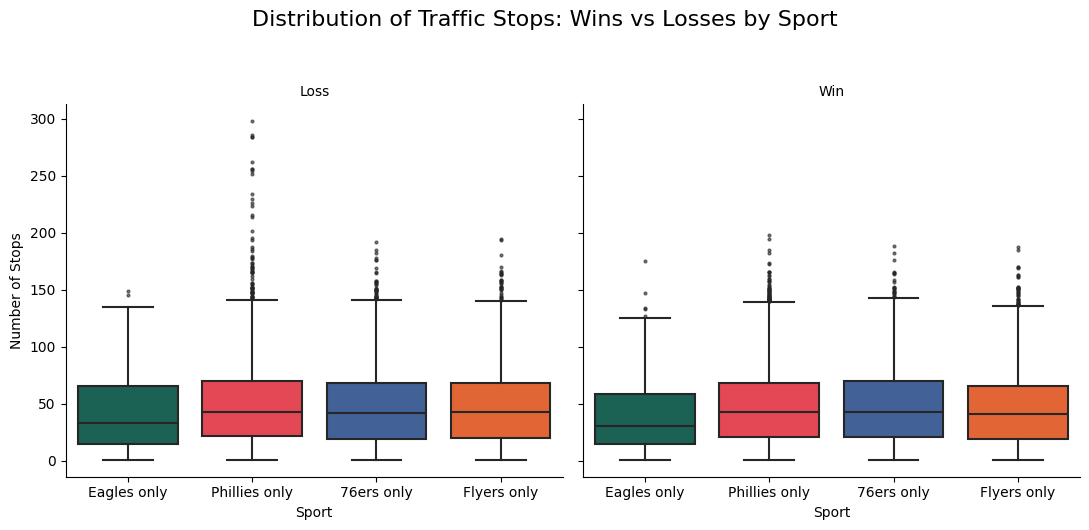

In [159]:
plot_df = agg_df_filled.copy()

# create outcome column (Win / Loss / No Game)
plot_df['outcome'] = plot_df.apply(
    lambda row: 'No Game' if 'No game' in str(row['pure_gameday_type']) else
                ('Win' if row.get('eagles_win') == True or 
                          row.get('phillies_win') == True or 
                          row.get('sixers_win') == True or 
                          row.get('flyers_win') == True else 'Loss'),
    axis=1
)

plot_df = plot_df[plot_df['outcome'] != 'No Game']

g = sns.catplot(
    data=plot_df,
    x='pure_gameday_type',
    y='stop_count',
    col='outcome',           
    kind='box',
    height=5,
    aspect=1.1,
    order=['Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,
    sharey=True,            # each subplot can have its own scale
    showfliers=True,
    flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.6}
)

g.set_axis_labels('Sport', 'Number of Stops')
g.set_titles("{col_name}")                    # Shows "Win" or "Loss" as title
g.fig.suptitle('Distribution of Traffic Stops: Wins vs Losses by Sport', 
               fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

Analysis of the above: there does not seem to be much variation in the number of stops across the 4 sports and based on the outcome.

In [160]:
# creating barplots for arrest rate
agg_df_filled['arrest_rate'] = (agg_df_filled['arrest_count'] / agg_df_filled['stop_count']) * 100
agg_df_filled["arrest_rate"] = agg_df_filled["arrest_rate"].fillna(0)
agg_df_filled

,date,hour,stop_count,arrest_count,eagles_hgame,eagles_win,eagles_point_diff,sixers_hgame,sixers_win,sixers_point_diff,phillies_hgame,phillies_win,phillies_point_diff,flyers_hgame,flyers_win,flyers_point_diff,pure_gameday_type,arrest_rate
0,2014-01-01,0,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game,0.000000
1,2014-01-01,1,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game,0.000000
2,2014-01-01,2,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game,0.000000
3,2014-01-01,3,2.0,0.0,False,NaN,NaN,False,1.0,12.0,False,NaN,NaN,False,NaN,NaN,No game,0.000000
4,2014-01-01,4,0.0,0.0,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,No game,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37555,2018-04-14,19,112.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game,0.892857
37556,2018-04-14,20,107.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game,0.934579
37557,2018-04-14,21,43.0,1.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game,2.325581
37558,2018-04-14,22,3.0,2.0,False,NaN,NaN,False,NaN,NaN,False,1.0,5.0,False,NaN,NaN,No game,66.666667


Text(0.5, 1.05, 'Arrest Rate: Wins vs Losses by Sport')

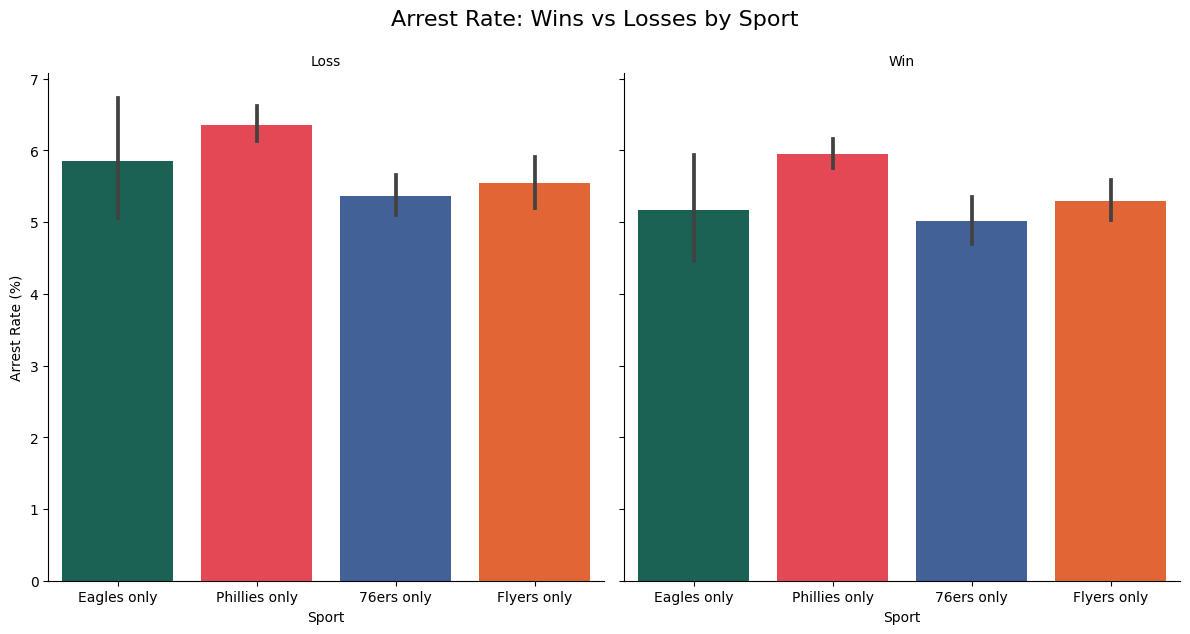

In [161]:
plot_df = agg_df_filled.copy()

# create outcome column (Win / Loss / No Game)
plot_df['outcome'] = plot_df.apply(
    lambda row: 'No Game' if 'No game' in str(row['pure_gameday_type']) else
                ('Win' if row.get('eagles_win') == True or 
                          row.get('phillies_win') == True or 
                          row.get('sixers_win') == True or 
                          row.get('flyers_win') == True else 'Loss'),
    axis=1
)

plot_df = plot_df[plot_df['outcome'] != 'No Game']


g = sns.catplot(
    data=plot_df,
    x='pure_gameday_type',
    y='arrest_rate',
    col='outcome',   
    kind='bar',
    height=6,
    aspect=1.0,
    order=['Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,           
    errorbar=('ci', 95),
    sharey=True,                    
    dodge=False
)

g.set_axis_labels('Sport', 'Arrest Rate (%)')
g.set_titles("{col_name}")            # Shows "Win" and "Loss" as titles
g.fig.suptitle('Arrest Rate: Wins vs Losses by Sport', fontsize=16, y=1.05)

Analysis of the above: seems like there is minimal variation in arrest rates based on the outcomes of the games. They're all very slightly lower when the teams win though.

In [162]:
plot_df

,date,hour,stop_count,arrest_count,eagles_hgame,eagles_win,eagles_point_diff,sixers_hgame,sixers_win,sixers_point_diff,phillies_hgame,phillies_win,phillies_point_diff,flyers_hgame,flyers_win,flyers_point_diff,pure_gameday_type,arrest_rate,outcome
120,2014-01-06,0,1.0,0.0,False,NaN,NaN,True,0.0,-31.0,False,NaN,NaN,False,NaN,NaN,76ers only,0.000000,Loss
123,2014-01-06,3,1.0,1.0,False,NaN,NaN,True,0.0,-31.0,False,NaN,NaN,False,NaN,NaN,76ers only,100.000000,Loss
130,2014-01-06,10,1.0,0.0,False,NaN,NaN,True,0.0,-31.0,False,NaN,NaN,False,NaN,NaN,76ers only,0.000000,Loss
131,2014-01-06,11,1.0,0.0,False,NaN,NaN,True,0.0,-31.0,False,NaN,NaN,False,NaN,NaN,76ers only,0.000000,Loss
132,2014-01-06,12,1.0,0.0,False,NaN,NaN,True,0.0,-31.0,False,NaN,NaN,False,NaN,NaN,76ers only,0.000000,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37483,2018-04-11,19,142.0,6.0,False,NaN,NaN,True,1.0,35.0,True,1.0,1.0,False,0.0,-7.0,Phillies only,4.225352,Win
37484,2018-04-11,20,104.0,4.0,False,NaN,NaN,True,1.0,35.0,True,1.0,1.0,False,0.0,-7.0,Phillies only,3.846154,Win
37485,2018-04-11,21,66.0,2.0,False,NaN,NaN,True,1.0,35.0,True,1.0,1.0,False,0.0,-7.0,Phillies only,3.030303,Win
37486,2018-04-11,22,75.0,5.0,False,NaN,NaN,True,1.0,35.0,True,1.0,1.0,False,0.0,-7.0,Phillies only,6.666667,Win


The groupby above is wrong, the below should be right. Groups by (Hour, Sport, Outcome) so that we can plot the average number of stops per hour of the day across every gameday for each sport.

In [163]:
plot_df_avg_stops = plot_df.copy()   

plot_df_avg_stops['outcome'] = plot_df_avg_stops.apply(
    lambda row: 'No Game' if 'No game' in str(row['pure_gameday_type']) else
                ('Win' if (row.get('eagles_win') == True or 
                           row.get('phillies_win') == True or 
                           row.get('sixers_win') == True or 
                           row.get('flyers_win') == True) 
                 else 'Loss'),
    axis=1
)
plot_df_games = plot_df[plot_df['outcome'] != 'No Game'].copy()

# compute average stops per hour per day, grouped by sport + outcome
hourly_avg_outcome = (
    plot_df_avg_stops
    .groupby(['hour', 'pure_gameday_type', 'outcome'])
    .agg(
        total_stops=('stop_count', 'sum'),
        num_days=('date', 'nunique')        # number of unique days for this sport + outcome
    )
    .reset_index()
)

hourly_avg_outcome['avg_stops_per_day'] = hourly_avg_outcome['total_stops'] / hourly_avg_outcome['num_days']

hourly_avg_outcome

,hour,pure_gameday_type,outcome,total_stops,num_days,avg_stops_per_day
0,0,76ers only,Loss,5460.0,102,53.529412
1,0,76ers only,Win,4514.0,80,56.425000
2,0,Eagles only,Loss,962.0,12,80.166667
3,0,Eagles only,Win,1313.0,20,65.650000
4,0,Flyers only,Loss,3501.0,62,56.467742
...,...,...,...,...,...,...
187,23,Eagles only,Win,858.0,20,42.900000
188,23,Flyers only,Loss,3125.0,62,50.403226
189,23,Flyers only,Win,4893.0,99,49.424242
190,23,Phillies only,Loss,9506.0,162,58.679012


In [164]:
hourly_avg_outcome["pure_gameday_type"].value_counts()

pure_gameday_type
76ers only       48
Eagles only      48
Flyers only      48
Phillies only    48
Name: count, dtype: int64

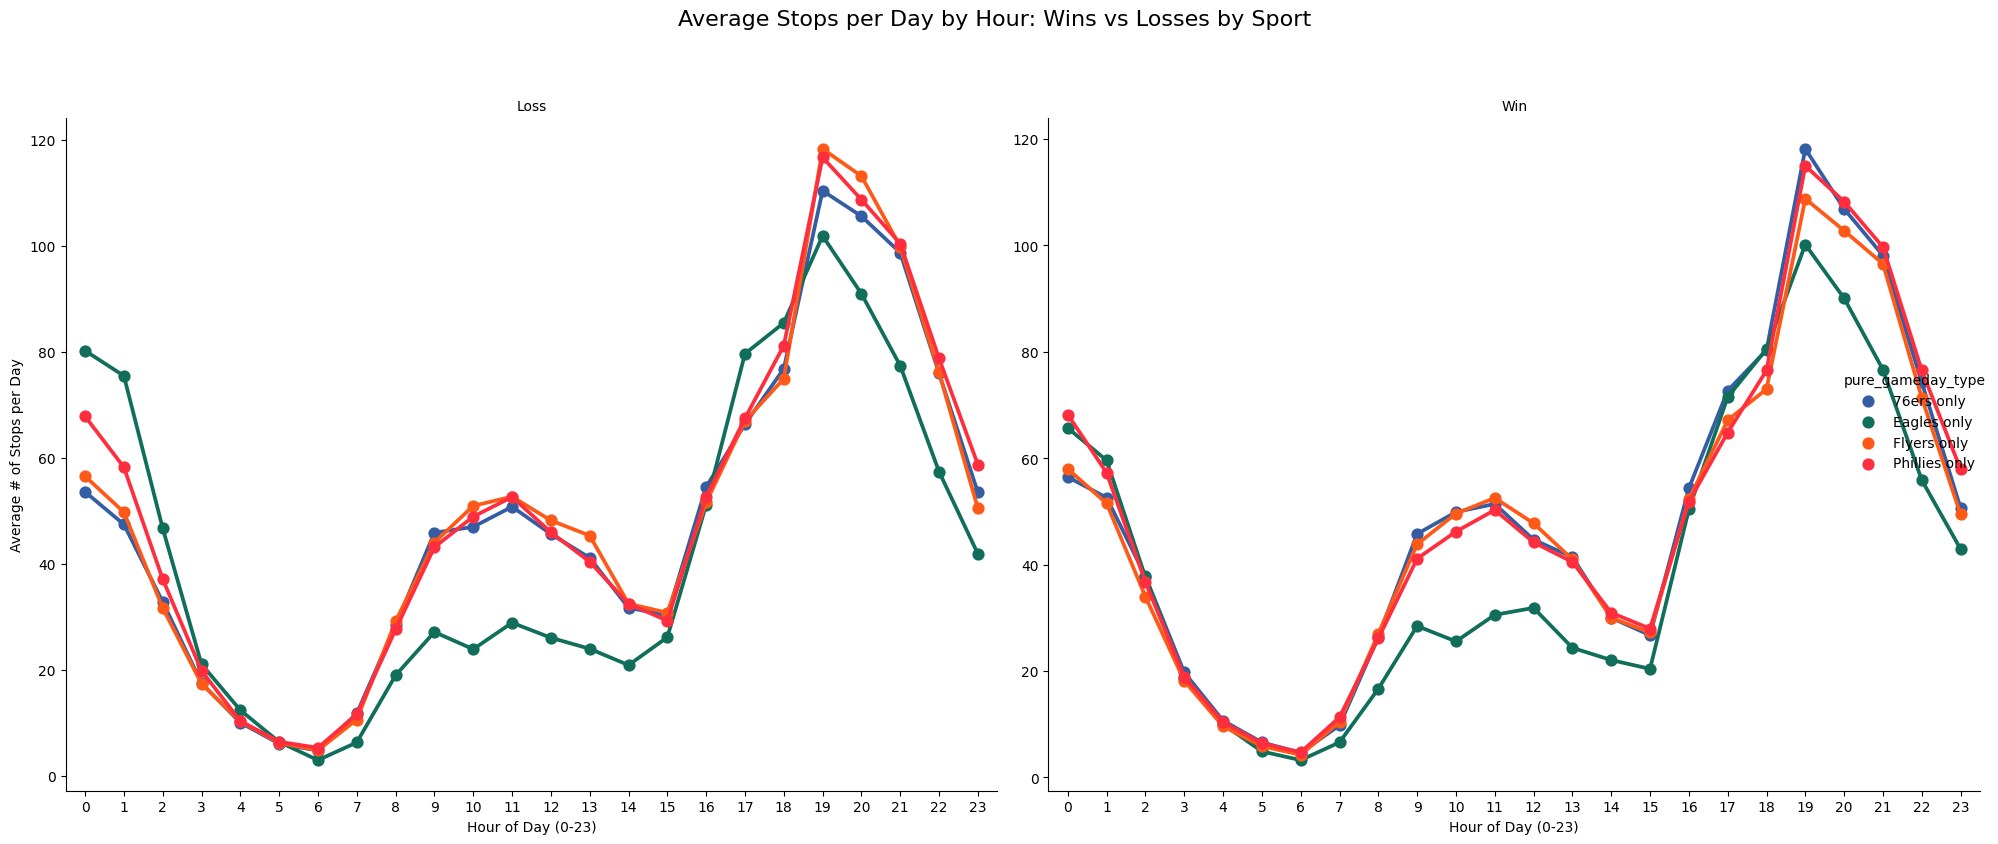

In [165]:
g = sns.catplot(
    data=hourly_avg_outcome,
    x='hour',
    y='avg_stops_per_day',
    hue='pure_gameday_type',       
    col='outcome',                 
    kind='point',                
    height=5,
    aspect=1.6,
    palette=custom_colors,          
    sharey=False,                   
    # errorbar=('ci', 95)           
)

g.set_axis_labels('Hour of Day (0-23)', 'Average # of Stops per Day')
g.set_titles("{col_name}")          
g.fig.suptitle('Average Stops per Day by Hour: Wins vs Losses by Sport', 
               fontsize=16, y=1.05)

g.fig.set_size_inches(20, 8)

plt.tight_layout()
plt.show()

Honestly can't really glean anything from the above line plot. Maybe just that there is a peak in stops around midnight-1AM for Eagles when they lose. But these plots also don't really take into account the actual game times so I feel like it's hard to take anything from these.